In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [66]:
coloumns_name = ['Length', 'Left', 'Right', 'Bottom', 'Top', 'Diagonal']
data = pd.read_csv('bank2.dat', delim_whitespace=True, header=None, names=coloumns_name)
data.head()

,Length,Left,Right,Bottom,Top,Diagonal
0,214.8,131.0,131.1,9.0,9.7,141.0
1,214.6,129.7,129.7,8.1,9.5,141.7
2,214.8,129.7,129.7,8.7,9.6,142.2
3,214.8,129.7,129.6,7.5,10.4,142.0
4,215.0,129.6,129.7,10.4,7.7,141.8


In [67]:
data['Class'] = ['Genuine'] * 100 + ['Counterfeit'] * 100
data.head()

,Length,Left,Right,Bottom,Top,Diagonal,Class
0,214.8,131.0,131.1,9.0,9.7,141.0,Genuine
1,214.6,129.7,129.7,8.1,9.5,141.7,Genuine
2,214.8,129.7,129.7,8.7,9.6,142.2,Genuine
3,214.8,129.7,129.6,7.5,10.4,142.0,Genuine
4,215.0,129.6,129.7,10.4,7.7,141.8,Genuine


In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Length    200 non-null    float64
 1   Left      200 non-null    float64
 2   Right     200 non-null    float64
 3   Bottom    200 non-null    float64
 4   Top       200 non-null    float64
 5   Diagonal  200 non-null    float64
 6   Class     200 non-null    object 
dtypes: float64(6), object(1)
memory usage: 11.1+ KB


In [69]:
data.isna().sum()

Length      0
Left        0
Right       0
Bottom      0
Top         0
Diagonal    0
Class       0
dtype: int64

In [70]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Length,200.0,214.8960,0.376554,213.8,214.6,214.90,215.100,216.3
Left,200.0,130.1215,0.361026,129.0,129.9,130.20,130.400,131.0
Right,200.0,129.9565,0.404072,129.0,129.7,130.00,130.225,131.1
Bottom,200.0,9.4175,1.444603,7.2,8.2,9.10,10.600,12.7
Top,200.0,10.6505,0.802947,7.7,10.1,10.60,11.200,12.3
Diagonal,200.0,140.4835,1.152266,137.8,139.5,140.45,141.500,142.4


# Kdeplot

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


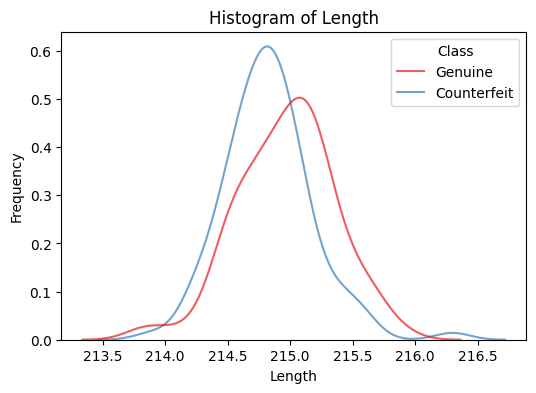

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


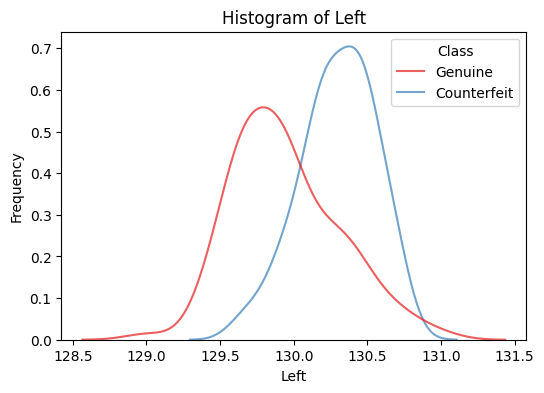

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


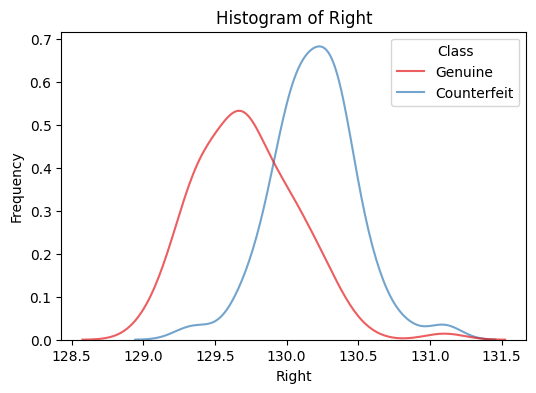

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


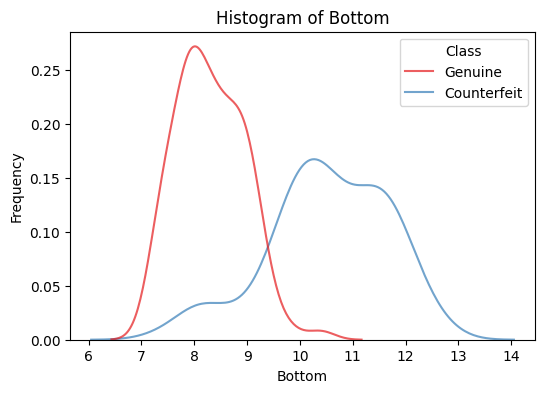

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


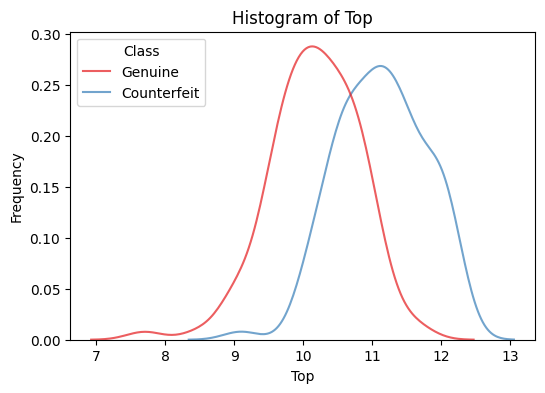

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


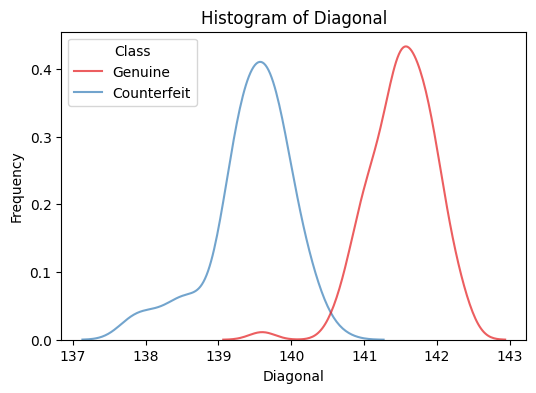

In [71]:
for col in data.drop(columns='Class').columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=data, x=col, hue="Class", palette="Set1", alpha=0.7)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f'Histogram of {col}')
    plt.show()

In [72]:
counterfeit = data[data['Class'] == 'Counterfeit'] # 或是用 data.iloc或是用 data.iloc[:100, :]
genuine = data[data['Class'] == 'Genuine'] # data.iloc[101:200, :]

# Boxplot

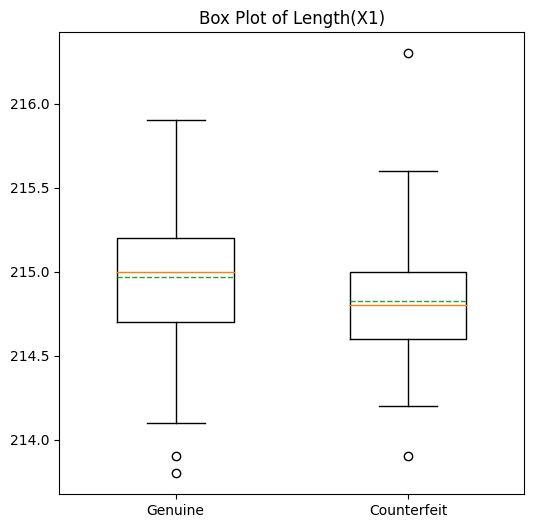

In [73]:
fig, ax = plt.subplots(figsize = (6, 6))
ax.boxplot([genuine['Length'], counterfeit['Length']],  labels=['Genuine', 'Counterfeit'], widths=0.5, meanline = True, showmeans = True)

plt.title('Box Plot of Length(X1)')

plt.show()

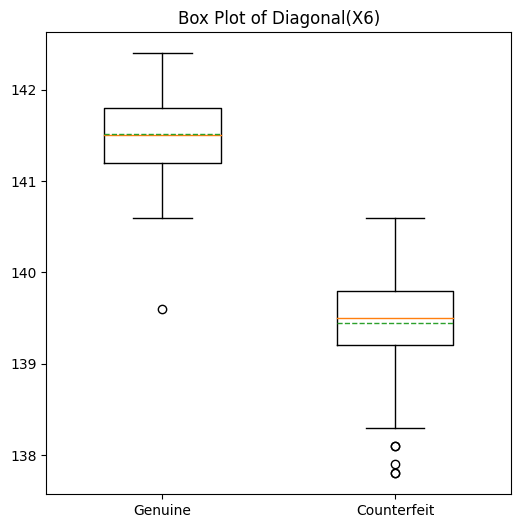

In [74]:
fig, ax = plt.subplots(figsize = (6, 6))
ax.boxplot([genuine['Diagonal'], counterfeit['Diagonal']],  labels=['Genuine', 'Counterfeit'], widths=0.5, meanline = True, showmeans = True)

plt.title('Box Plot of Diagonal(X6)')

plt.show()

# 2D Scatterplot

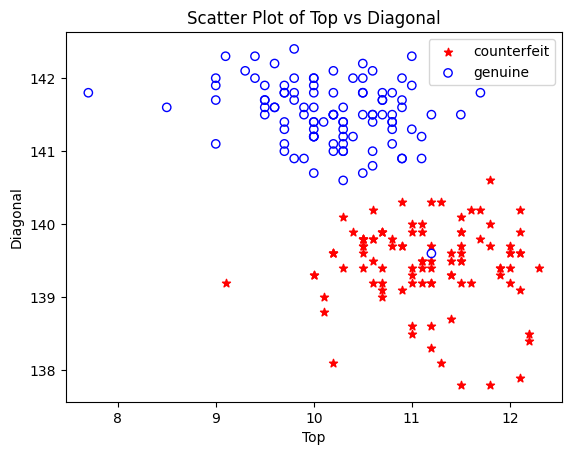

In [75]:
plt.scatter(counterfeit['Top'], counterfeit['Diagonal'], color='r', marker='*', label='counterfeit')
plt.scatter(genuine['Top'], genuine['Diagonal'], color='b', marker='o', label='genuine',  facecolors='none')

plt.xlabel('Top')
plt.ylabel('Diagonal')
plt.title('Scatter Plot of Top vs Diagonal')

plt.legend()
plt.show()

# 3D Scatterplot

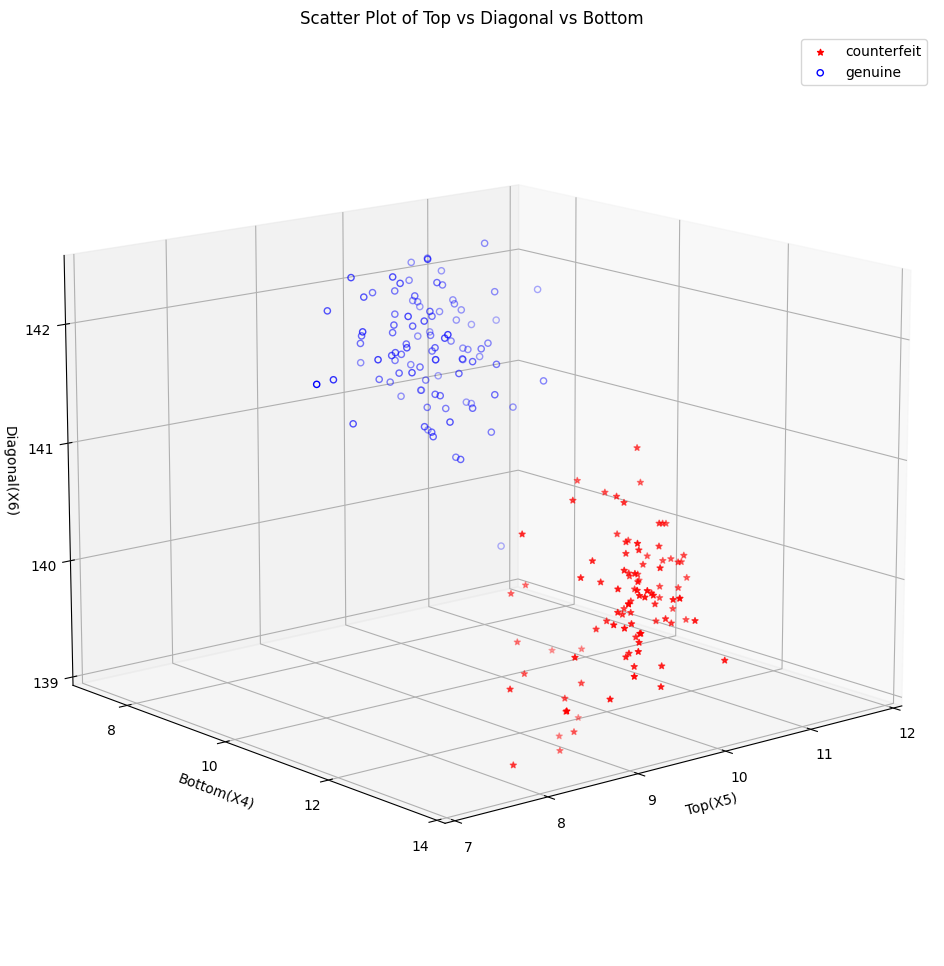

In [92]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(counterfeit['Top'], counterfeit['Bottom'], counterfeit['Diagonal'], color='r', marker='*', label='counterfeit')
ax.scatter(genuine['Top'], genuine['Bottom'], genuine['Diagonal'], color='b', marker='o', label='genuine', facecolors='none')

ax.set_xlim(7, 12)
ax.set_ylim(7, 14)
ax.set_zlim(139, 142.5)

# 設定每個軸刻度
ax.set_xticks(np.arange(7, 13, 1))
ax.set_yticks(np.arange(8, 15, 2))
ax.set_zticks(np.arange(139, 143, 1))

ax.set_xlabel('Top(X5)')
ax.set_ylabel('Bottom(X4)')
ax.set_zlabel('Diagonal(X6)')
ax.set_title('Scatter Plot of Top vs Diagonal vs Bottom')
ax.invert_xaxis()
ax.legend()
ax.view_init(elev=14, azim=50)  # 調整視角 elev=仰角, azim=方位角
plt.show()


# Pairplot

c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

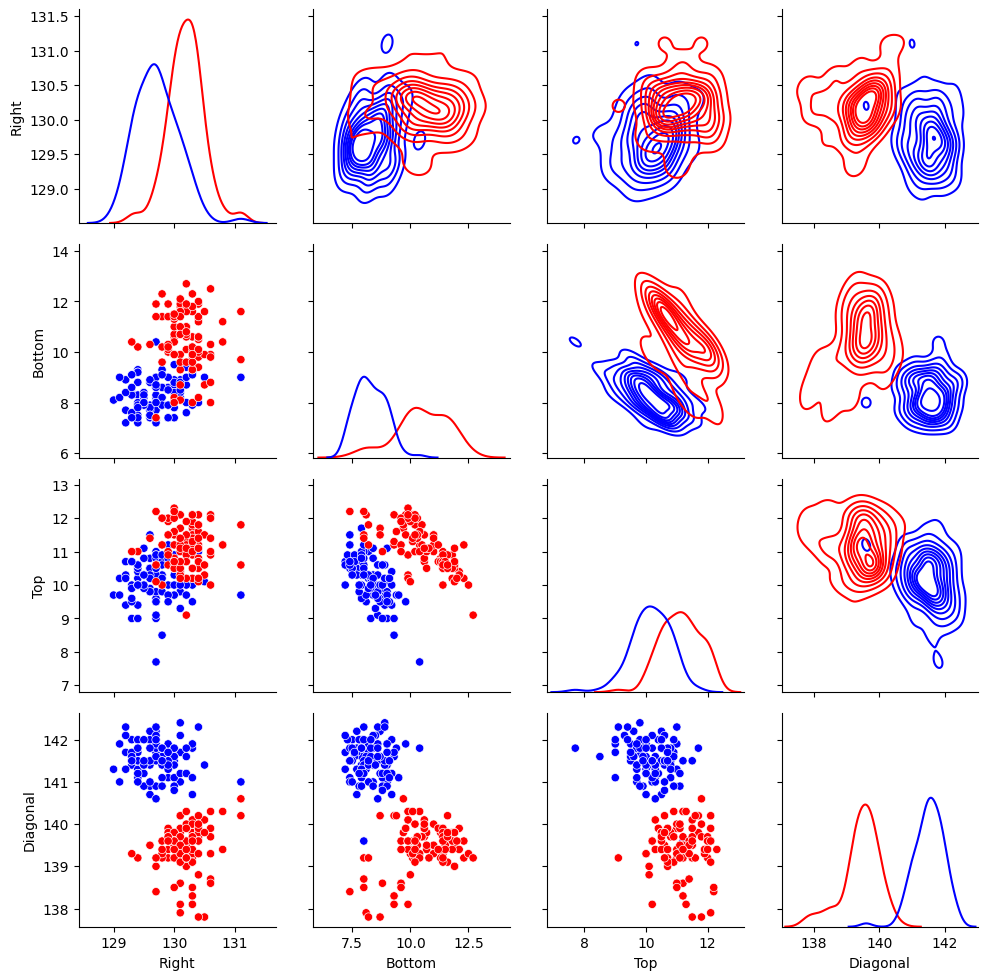

In [77]:
pic = sns.PairGrid(data, 
                   vars=['Right', 'Bottom', 'Top', 'Diagonal'], 
                   hue='Class', 
                #    markers=['o', '*'],  # 真品用圓圈（o），假貨用方塊（s）
                #    diag_kind='kde', 
                   palette={'Genuine': 'b', 'Counterfeit': 'r'})
pic.map_lower(sns.scatterplot)
pic.map_upper(sns.kdeplot)
pic.map_diag(sns.kdeplot)
plt.show()

---

# Logistic Regression with StandardScaler

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm

In [79]:
X = data.drop(columns=['Class'])
y = data['Class']

In [80]:
le = LabelEncoder()
y = le.fit_transform(y)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [82]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
lr = LogisticRegression(random_state=42, penalty=None)
model = lr.fit(X_train_scaled, y_train)

In [88]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[19  0]
 [ 1 20]]
0.975


In [89]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print("\nLogistic Regression Coefficients:\n", coefficients)

print("\nIntercept (β0):", model.intercept_[0])

print("\nModel Accuracy:", model.score(X_test_scaled, y_test))

print(classification_report(y_test, y_pred))


Logistic Regression Coefficients:
     Feature  Coefficient
0    Length    -0.750018
1      Left    -0.091612
2     Right    -2.393450
3    Bottom    -8.567113
4       Top    -8.458683
5  Diagonal    12.911090

Intercept (β0): 0.8133864263795936

Model Accuracy: 0.975
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.95      0.98        21

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



In [100]:
constant = sm.add_constant(X)

# 使用 statsmodels 的 Logit（邏輯回歸）
model = sm.Logit(y, constant)   
result = model.fit_regularized(method='l1', alpha=0.01)

# 顯示完整的 summary（包含 p 值、t 值）
print(result.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.002174041962487562
            Iterations: 131
            Function evaluations: 136
            Gradient evaluations: 131
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  200
Model:                          Logit   Df Residuals:                      193
Method:                           MLE   Df Model:                            6
Date:                Thu, 20 Mar 2025   Pseudo R-squ.:                  0.9994
Time:                        16:39:59   Log-Likelihood:              -0.083416
converged:                       True   LL-Null:                       -138.63
Covariance Type:            nonrobust   LLR p-value:                 6.587e-57
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 1 out of 7 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


# DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [ ]:
dtc = DecisionTreeClassifier(random_state=0)
model2 = dtc.fit(X_train, y_train)

In [ ]:
y_pred2 = model2.predict(X_test)
y_proba2 = model2.predict_proba(X_test)
print(confusion_matrix(y_test, y_pred2))
print(accuracy_score(y_test, y_pred2))

[[19  0]
 [ 1 20]]
0.975


In [ ]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

 Counterfeit       0.95      1.00      0.97        19
     Genuine       1.00      0.95      0.98        21

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



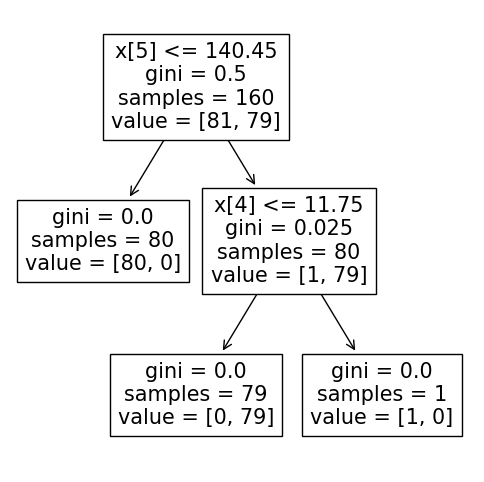

In [ ]:
from sklearn import tree
plt.figure(figsize=(6, 6))
tree.plot_tree(dtc)
plt.show()

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import load_iris

# 加載 Iris 數據集（僅使用兩類，變成二元分類）
iris = load_iris()
X = iris.data[:100, :2]  # 選擇前 100 個數據（兩類），並取前兩個特徵
y = iris.target[:100]

# 添加截距項（R `glm()` 會自動加，但 Python 需要手動加）
X = sm.add_constant(X)

# 使用 statsmodels 的 Logit（邏輯回歸）
model = sm.Logit(y, X)
result = model.fit()

# 顯示完整的 summary（包含 p 值、t 值）
print(result.summary())


         Current function value: 0.000000
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  100
Model:                          Logit   Df Residuals:                       97
Method:                           MLE   Df Model:                            2
Date:                Thu, 20 Mar 2025   Pseudo R-squ.:                   1.000
Time:                        16:15:22   Log-Likelihood:            -7.2517e-06
converged:                      False   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 7.889e-31
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -289.9836   1.29e+06     -0.000      1.000   -2.53e+06    2.53e+06
x1           126.2102   8.36e+05      0.000      1.000   -1.64e+0

c:\Users\USER\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
